In [1]:
import numpy as np
import math
import statistics
import pandas as pd
import pyswarms as ps
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, mean_squared_error
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
def yes_function(x, y, a, kappa, lam, gamma=1):
    return 1 - np.maximum(0.0, ((1-x)**kappa + (1-y)**kappa - (1-a)**kappa))**(1/kappa)

def no_function(x, y, a, kappa, lam, gamma=1):
    return np.maximum(0.0, (x**lam + y**lam - a**lam))**(1/lam)

def maybe_function(x, y, a, kappa, lam, gamma=1):
    if x is None or y is None:
        return 0
    if gamma == 0:
        return 0
    a = np.clip(a, 1e-6, 1 - 1e-6)
    x = np.clip(x, 0, 1)
    y = np.clip(y, 0, 1)
    value = gamma*(1/a)*x*y + (1-gamma)*(1 - (1/(1-a))*(1-x)*(1-y))
    return statistics.median([0, 1, value])

def classification(x, y, a, kappa, lam, gamma):
    if x < a and y < a:
        return no_function(x, y, a, 1, lam, 1)
    elif x > a and y > a:
        return yes_function(x, y, a, kappa, 1, 1)
    else:
        return maybe_function(x, y, a, 1, 1, gamma)

def classification_vec(values, diffs, a, kappa, lam, gamma):
    if values.size == 0 or diffs.size == 0:
        return np.zeros_like(values)

    results = np.zeros_like(values, dtype=float)
    mask_no    = (values < a) & (diffs < a)
    mask_yes   = (values > a) & (diffs > a)
    mask_maybe = ~(mask_no | mask_yes)

    if np.any(mask_no):
        results[mask_no] = no_function(values[mask_no], diffs[mask_no], a, 1, lam, 1)
    if np.any(mask_yes):
        results[mask_yes] = yes_function(values[mask_yes], diffs[mask_yes], a, kappa, 1, 1)
    if np.any(mask_maybe):
        for idx in np.where(mask_maybe)[0]:
            results[idx] = maybe_function(values[idx], diffs[idx], a, 1, 1, gamma)

    return np.round(results, 4)

def evaluate_params(X, y, params):
    n_features = X.shape[1]
    value = np.abs(X[:, 0] - params[5])
    i = 6
    for j in range(n_features - 1):
        diff = np.abs(X[:, j+1] - params[i])
        value = classification_vec(value, diff,
                                   params[0], params[1], params[2], params[3])
        i += 1

    error = np.exp2(np.abs(value - y))
    #error = np.mean(np.abs(value - y))
    calc_class   = (value >= params[0]).astype(int)
    target_class = (y >= params[0]).astype(int)
    mean_error   = np.mean(error)
    f1           = f1_score(target_class, calc_class, zero_division=0)

    return value, error, calc_class, target_class, mean_error, f1

def make_cost_func(X_train, y_train):
    n_features = X_train.shape[1]

    def cost_func(position_matrix):
        n_particles = position_matrix.shape[0]
        costs = np.zeros(n_particles)

        for i, param in enumerate(position_matrix):
            try:
                param = np.clip(param, 0, 1)
                param[0] = np.clip(param[0], 0.1, 0.9)
                param[1] = param[1] * 3
                param[2] = param[2] * 3

                value = np.abs(X_train[:, 0] - param[5])
                idx = 6
                for j in range(n_features - 1):
                    diff = np.abs(X_train[:, j+1] - param[idx])
                    value = classification_vec(value, diff,
                                               param[0], param[1], param[2], param[3])
                    idx += 1

                if np.any(np.isnan(value)) or np.any(np.isinf(value)):
                    costs[i] = 1e9
                    continue

                error    = np.exp2(np.abs(value - y_train))
                #error    = np.mean(np.abs(value - y_train))
                fitness1 = 1.0 / (math.sqrt(np.mean(error)) + 1e-8)

                calc_class   = (value >= param[0]).astype(int)
                target_class = (y_train >= param[0]).astype(int)
                fitness2     = f1_score(target_class, calc_class, zero_division=0)

                if np.isnan(fitness1) or np.isnan(fitness2):
                    costs[i] = 1e9
                    continue

                costs[i] = -(param[4] * fitness1 + (1 - param[4]) * fitness2)
                #costs[i] = error

            except Exception as e:
                print(f"Cost calculation failed: {e}")
                costs[i] = 1e9

        return costs

    return cost_func

def run_pso_on_fold(X_train_fold, y_train_fold):
    n_genes=100

    bounds = (
        np.zeros(n_genes),  
        np.ones(n_genes)     
    )

    options = {
        'c1': 0.5,  
        'c2': 0.5,   
        'w':  0.9    
    }

    optimizer = ps.single.GlobalBestPSO(
        n_particles=30,
        dimensions=100,
        options=options,
        bounds=bounds
    )

    cost_func = make_cost_func(X_train_fold, y_train_fold)

    best_cost, best_pos = optimizer.optimize(
        cost_func,
        iters=100,
        verbose=False
    )

    best_params = best_pos.copy()
    best_params = np.clip(best_params, 0, 1)
    best_params[0] = np.clip(best_params[0], 0.1, 0.9) 
    best_params[1] = best_params[1] * 3                  
    best_params[2] = best_params[2] * 3                  

    return best_params, best_cost

def calculate_param_using_pso(data: pd.DataFrame, n_splits: int = 10):
    df = data.copy()
    X = df.iloc[:, :-1].to_numpy()
    y = df.iloc[:, -1].to_numpy()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    cv_results = []

    print(f"{n_splits}-fold cross-validation")
    print("=" * 60)

    for fold_idx, (train_index, val_index) in enumerate(kf.split(X), start=1):
        print(f"\n--- Fold {fold_idx}/{n_splits} ---")

        X_train_fold = X[train_index]
        y_train_fold = y[train_index]
        X_val_fold   = X[val_index]
        y_val_fold   = y[val_index]

        best_params, best_cost = run_pso_on_fold(X_train_fold, y_train_fold)

        (train_values, train_errors,
         train_calc_class, train_target_class,
         train_mean_error, train_f1) = evaluate_params(X_train_fold, y_train_fold, best_params)

        (val_values, val_errors,
         val_calc_class, val_target_class,
         val_mean_error, val_f1) = evaluate_params(X_val_fold, y_val_fold, best_params)

        print(f"  Train -> Mean Error: {train_mean_error:.4f} | F1: {train_f1:.4f}")
        print(f"  Val   -> Mean Error: {val_mean_error:.4f}  | F1: {val_f1:.4f}")
        print(f"  Params -> a={best_params[0]:.4f}, kappa={best_params[1]:.4f}, "
              f"lambda={best_params[2]:.4f}, gamma={best_params[3]:.4f}")

        fold_result = {
            "fold":         fold_idx,
            "train_indices": train_index.tolist(),
            "val_indices":   val_index.tolist(),
            "train_size":    len(train_index),
            "val_size":      len(val_index),

            "best_params":    best_params,
            "a":              best_params[0],
            "kappa":          best_params[1],
            "lambda":         best_params[2],
            "gamma":          best_params[3],
            "fitness_weight": best_params[4],
            "binary_params":  best_params[5:].tolist(),
            "best_cost":      best_cost,

            "train_mean_error":  train_mean_error,
            "train_f1":          train_f1,
            "train_values":      train_values.tolist(),
            "train_errors":      train_errors.tolist(),
            "train_calc_class":  train_calc_class.tolist(),
            "train_target_class": train_target_class.tolist(),

            "val_mean_error":  val_mean_error,
            "val_f1":          val_f1,
            "val_values":      val_values.tolist(),
            "val_errors":      val_errors.tolist(),
            "val_calc_class":  val_calc_class.tolist(),
            "val_target_class": val_target_class.tolist(),

            "X_train_fold": X_train_fold.tolist(),
            "y_train_fold": y_train_fold.tolist(),
            "X_val_fold":   X_val_fold.tolist(),
            "y_val_fold":   y_val_fold.tolist(),
        }
        cv_results.append(fold_result)

    print("\n" + "=" * 60)
    print("=" * 60)

    summary_df = pd.DataFrame([{
        "Fold":            r["fold"],
        "Train Size":      r["train_size"],
        "Val Size":        r["val_size"],
        "Train MeanError": round(r["train_mean_error"], 4),
        "Train F1":        round(r["train_f1"], 4),
        "Val MeanError":   round(r["val_mean_error"], 4),
        "Val F1":          round(r["val_f1"], 4),
        "a":               round(r["a"], 4),
        "kappa":           round(r["kappa"], 4),
        "lambda":          round(r["lambda"], 4),
        "gamma":           round(r["gamma"], 4),
        "PSO Cost":        round(r["best_cost"], 4),
    } for r in cv_results])

    print(summary_df.to_string(index=False))
    print(f"\nVal F1:         {summary_df['Val F1'].mean():.4f} ± {summary_df['Val F1'].std():.4f}")
    print(f" Val Mean Error: {summary_df['Val MeanError'].mean():.4f} ± {summary_df['Val MeanError'].std():.4f}")

    best_fold_idx    = summary_df["Val F1"].idxmax()
    best_fold_result = cv_results[best_fold_idx]
    print(f"\nThe best fold: Fold {best_fold_result['fold']}")

    return cv_results, best_fold_result, summary_df

In [3]:
def show_results(data, mean_error, gamma_result, lam_result, kappa_result, a_result):
    target_values = data[['target']].values
    value = data[['calc_value']].values
    MSE = mean_squared_error(target_values, value)
    RMSE = math.sqrt(MSE)
    print('Results:')
    if all(col in data.columns for col in ['value','error']):
      print(data.drop(columns=['value','error']))
    else:
      print(data)
    print('\u03B3 = ', round(gamma_result, 4))
    print('\u03BB = ', round(lam_result, 4))
    print('\u03BA = ', round(kappa_result, 4))
    print('a = ', round(a_result, 4))
    print('Mean squared error = ', round(MSE, 4))
    print('Root Mean Square Error = ', round(RMSE, 4))

In [4]:
def remove_outliers_iqr(df, features):
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[feature] >= Q1 - 1.5 * IQR) & (df[feature] <= Q3 + 1.5 * IQR)]
    return df

In [5]:
def calculate_tests(target_values, value):
  print('Accuracy score = ', accuracy_score(target_values, value))
  print('F1 = ', f1_score(target_values, value))
  print('Precision = ', precision_score(target_values, value))
  print('Recall = ', recall_score(target_values, value))
  confusion_matrix = metrics.confusion_matrix(target_values, value)
  cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
  cm_display.plot()
  plt.show()

In [6]:
from scipy import stats
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing(as_frame=True)
df = california_housing.frame

df_o = remove_outliers_iqr(df, ['MedInc', 'HouseAge','AveRooms','AveBedrms','Population','AveOccup','MedHouseVal'])
df_o = df_o.rename(columns={'MedHouseVal': 'target'})
df_final = df_o.iloc[:,[0,1,2,3,4,5,6,7,8]]

X_train, X_test = train_test_split(df_final, test_size=0.2, random_state=2)

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=df_final.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=df_final.columns)

print(X_train_scaled.head())

     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  0.228766  0.666667  0.651972   0.401786    0.179100  0.544350  0.643996   
1  0.426172  0.333333  0.402059   0.571212    0.716399  0.479006  0.134963   
2  0.389418  0.176471  0.550206   0.613858    0.437520  0.360870  0.063762   
3  0.377894  0.568627  0.299533   0.523724    0.267863  0.411922  0.174283   
4  0.271234  0.294118  0.541690   0.644239    0.299339  0.251665  0.170032   

   Longitude    target  
0   0.299591  0.193992  
1   0.651329  0.371411  
2   0.740286  0.387761  
3   0.606339  0.413612  
4   0.728016  0.252763  


In [7]:
start_time = time.time()
cv_results, best_fold_result, summary_df = calculate_param_using_pso(X_train_scaled)
print('time:', (time.time()-start_time)/60)

10-fold cross-validation

--- Fold 1/10 ---
  Train -> Mean Error: 1.5258 | F1: 0.9826
  Val   -> Mean Error: 1.5236  | F1: 0.9836
  Params -> a=0.1000, kappa=1.6583, lambda=1.7488, gamma=0.6096

--- Fold 2/10 ---
  Train -> Mean Error: 1.5155 | F1: 0.9830
  Val   -> Mean Error: 1.5228  | F1: 0.9808
  Params -> a=0.1000, kappa=2.2126, lambda=1.0521, gamma=0.0773

--- Fold 3/10 ---
  Train -> Mean Error: 1.4100 | F1: 0.9825
  Val   -> Mean Error: 1.4074  | F1: 0.9824
  Params -> a=0.1000, kappa=2.7203, lambda=2.9352, gamma=0.5590

--- Fold 4/10 ---
  Train -> Mean Error: 1.5145 | F1: 0.9833
  Val   -> Mean Error: 1.5065  | F1: 0.9780
  Params -> a=0.1000, kappa=1.0420, lambda=1.3540, gamma=0.4089

--- Fold 5/10 ---
  Train -> Mean Error: 1.3851 | F1: 0.9822
  Val   -> Mean Error: 1.3780  | F1: 0.9856
  Params -> a=0.1000, kappa=1.5862, lambda=1.0119, gamma=0.5641

--- Fold 6/10 ---
  Train -> Mean Error: 1.4170 | F1: 0.9817
  Val   -> Mean Error: 1.4107  | F1: 0.9836
  Params -> a=0.100

Accuracy score =  0.9661147477859068
F1 =  0.9827653740697219
Precision =  1.0
Recall =  0.9661147477859068


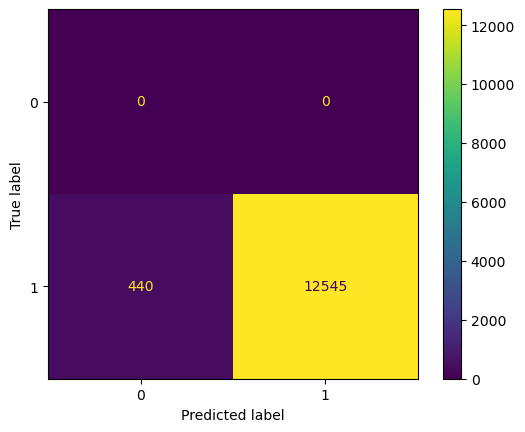

In [8]:
columns=len(X_train_scaled.columns)
X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], best_fold_result['a'], best_fold_result['kappa'], best_fold_result['lambda'], best_fold_result['gamma']), axis = 1)
  j += 1
X_train_scaled['calc_value_class'] = X_train_scaled.apply(lambda row: 0 if (row['calc_value']<= best_fold_result['a'])else 1, axis=1)
X_train_scaled['target_class'] = X_train_scaled.apply(lambda row: 0 if (row['target']<= best_fold_result['a'])else 1, axis=1)
calculate_tests(X_train_scaled[["calc_value_class"]].values, X_train_scaled[['target_class']].values)

In [9]:
columns=len(X_test_scaled.columns)
X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], best_fold_result['a'], best_fold_result['kappa'], best_fold_result['lambda'], best_fold_result['gamma']), axis = 1)
  j += 1
show_results(X_test_scaled, 0, 0, 0, 0, 0)

Results:
        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0     0.740705  0.431373  0.856210   0.529258    0.442556  0.609795  0.160468   
1     0.557004  0.686275  0.525870   0.203205    0.523765  0.761286  0.146652   
2     0.532832  0.392157  0.588852   0.227864    0.319799  0.492305  0.583422   
3     0.452807  0.686275  0.647610   0.522866    0.222222  0.313524  0.628055   
4     0.256592  1.000000  0.242021   0.207369    0.261882  0.498898  0.553666   
...        ...       ...       ...        ...         ...       ...       ...   
3242  0.517172  1.000000  0.624418   0.727244    0.340573  0.394231  0.510096   
3243  0.560497  0.098039  0.484323   0.328678    0.132515  0.329538  0.096706   
3244  0.678467  0.274510  0.436709   0.437477    0.589865  0.223366  0.129649   
3245  0.375994  0.431373  0.560195   0.475277    0.473088  0.512056  0.182784   
3246  0.385001  0.568627  0.383582   0.426398    0.241108  0.278919  0.117960   

      Longitude   

In [10]:
X_test_scaled['target_class'] = X_test_scaled.apply(lambda row: 0 if (row['target']<= best_fold_result['a'])else 1, axis=1)
X_test_scaled['calc_value_class'] = X_test_scaled.apply(lambda row: 0 if (row['calc_value']<= best_fold_result['a'])else 1, axis=1)

In [11]:
target_values = X_test_scaled[['target_class']].values
value = X_test_scaled[['calc_value_class']].values

Accuracy score =  0.9688943640283338
F1 =  0.9842014703582043
Precision =  0.9688943640283338
Recall =  1.0


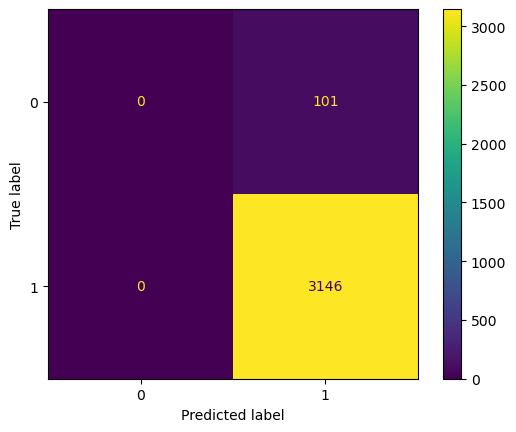

In [12]:
calculate_tests(target_values, value)